In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib inline

import os
while 'notebooks' in os.getcwd():
    os.chdir("../")

!pwd

/Users/msat/projects/SemanticPullbacks


In [2]:
import platform
platform.machine()

'arm64'

In [3]:
import torch
import math
from torch import nn, einsum
from torchvision.datasets import Imagenette
from torch.utils.data import DataLoader

import torch.nn.functional as F
from torchvision import transforms as T

from lib.dataset import get_imagenette, get_imagenet, get_examples, FromMyNormalizeToImageNet
from lib.pga import PGA
from lib.helpers import plot_example_grid, plot_function, show_images
from lib.surrogates import soften_module_inplace_

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
device = torch.device(device)
device

device(type='mps')

In [5]:
# dataset = "imagenet"
dataset = "imagenette"

if dataset == "imagenet":
    dataset = get_imagenet()
elif dataset == "imagenette":
    try:
        dataset = get_imagenette(download=True)
    except RuntimeError as e:
        # wierdly, Imagenette raises error if already downloaded (at least in some torchvision versions)
        print(e)
        dataset = get_imagenette(download=False)

seed = 314
generator = torch.Generator().manual_seed(seed)
loader = DataLoader(dataset, batch_size=5, shuffle=True, generator=generator)

In [6]:
it = iter(loader)

tensor(-1.) tensor(1.) tensor(-0.1629) tensor(0.4621)
images.shape = torch.Size([5, 3, 224, 224])
labels = [497, 566, 571, 482, 701]


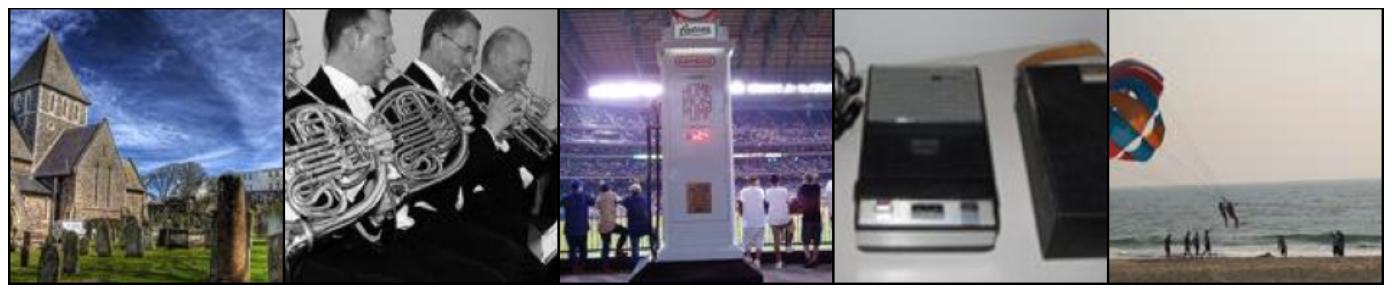

In [7]:
# images, labels = next(iter(loader))
images, labels = next(it)

print(images.min(), images.max(), images.mean(), images.std())
print(f"images.shape = {images.shape}")
print(f"labels = {labels.tolist()}")

plot_example_grid(images, nrow=5)

In [8]:
from torchvision.models import resnet50, resnet18, vgg11_bn, densenet121, vit_b_16, convnext_tiny, efficientnet_b0, resnet18, squeezenet1_1, resnext50_32x4d

model_cls = resnet18
# model_cls = resnet50
# model_cls = densenet121
# model_cls = vgg11_bn
model_cls = vit_b_16
# model_cls = resnet18
# model_cls = efficientnet_b0
# model_cls = squeezenet1_1
# model_cls = convnext_tiny
# model_cls = resnext50_32x4d

# backbone_std = model_cls(pretrained=True)
backbone = model_cls(pretrained=True)

/Users/msat/.venvs/quantus/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/msat/.venvs/quantus/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
model = nn.Sequential(FromMyNormalizeToImageNet(), backbone)

In [10]:
temperatures = {
    "ReLU": 0.3,
    "SiLU": 0.6,
    "GELU": 1.0,
    "MaxPool2d": 0.2,
    "LayerNorm": 1.0,
    "LayerNorm2d": 1.0,
    "MultiheadAttention": 1.2,
}
soften_module_inplace_(model, temperatures=temperatures)
model.to(device)


Sequential(
  (0): FromMyNormalizeToImageNet(
    (imagenet_norm): Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  )
  (1): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): SurrogateLayerNorm((768,), eps=1e-06, elementwise_affine=True, temperature=1.0)
          (self_attention): SurrogateMultiheadAttention(
            temperature=1.2
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): SurrogateLayerNorm((768,), eps=1e-06, elementwise_affine=True, temperature=1.0)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): SurrogateGELU(approximate='none', temperature=1.0)
            (2)

In [29]:
# use_cross_entropy_loss = True
use_cross_entropy_loss = False

alpha = 20

eps = 100
# eps = 250

# relative_alpha = True
relative_alpha = False
steps = 1
# steps = 2
# steps = 3
# steps = 5
# steps = 7
steps = 10
# steps = 15
# steps = 30

clip_margin = .0
pnorm = 2

self_explain = False
# self_explain = True

In [33]:
atk = PGA(model, eps=eps, alpha=alpha, steps=steps, clip_margin=clip_margin, self_explain=self_explain,
          use_cross_entropy_loss=use_cross_entropy_loss, pnorm=pnorm, relative_alpha=relative_alpha)
atk.set_mode_targeted_by_label()

Attack mode is changed to 'targeted(label)'.


In [ ]:
import quantus
from quantus import Metric, explain
import captum
# from quantus.metrics.base import Metric

In [14]:
quantus.MaxSensitivity().get_params

{'abs': False,
 'normalise': False,
 'return_aggregate': False,
 'aggregate_func': <function mean at 0x10e01fb30>,
 'normalise_func': <function quantus.functions.normalise_func.normalise_by_max(a: numpy.ndarray, normalise_axes: Sequence[int] | None = None) -> numpy.ndarray>,
 'normalise_func_kwargs': {},
 '_disable_warnings': False,
 '_display_progressbar': False,
 'a_axes': None,
 'nr_samples': 200,
 'similarity_func': <function quantus.functions.similarity_func.difference(a: <built-in function array>, b: <built-in function array>, **kwargs) -> <built-in function array>>,
 'norm_numerator': <function quantus.functions.norm_func.fro_norm(a: <built-in function array>) -> float>,
 'norm_denominator': <function quantus.functions.norm_func.fro_norm(a: <built-in function array>) -> float>,
 'perturb_func': functools.partial(<function batch_uniform_noise at 0x1432a3270>, lower_bound=0.2, upper_bound=None),
 'changed_prediction_indices_func': functools.partial(<function changed_prediction_ind

In [13]:
quantus.AVAILABLE_METRICS

{'Faithfulness': {'Faithfulness Correlation': quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation,
  'Faithfulness Estimate': quantus.metrics.faithfulness.faithfulness_estimate.FaithfulnessEstimate,
  'Pixel-Flipping': quantus.metrics.faithfulness.pixel_flipping.PixelFlipping,
  'Region Segmentation': quantus.metrics.faithfulness.region_perturbation.RegionPerturbation,
  'Monotonicity-Arya': quantus.metrics.faithfulness.monotonicity.Monotonicity,
  'Monotonicity-Nguyen': quantus.metrics.faithfulness.monotonicity_correlation.MonotonicityCorrelation,
  'Selectivity': quantus.metrics.faithfulness.selectivity.Selectivity,
  'SensitivityN': quantus.metrics.faithfulness.sensitivity_n.SensitivityN,
  'IROF': quantus.metrics.faithfulness.irof.IROF,
  'ROAD': quantus.metrics.faithfulness.road.ROAD,
  'Infidelity': quantus.metrics.faithfulness.infidelity.Infidelity,
  'Sufficiency': quantus.metrics.faithfulness.sufficiency.Sufficiency},
 'Robustness': {'Continuity Test'

In [15]:
quantus.AVAILABLE_XAI_METHODS_CAPTUM

['GradientShap',
 'IntegratedGradients',
 'DeepLift',
 'DeepLiftShap',
 'InputXGradient',
 'Saliency',
 'FeatureAblation',
 'Deconvolution',
 'FeaturePermutation',
 'Lime',
 'KernelShap',
 'LRP',
 'Gradient',
 'Occlusion',
 'LayerGradCam',
 'GuidedGradCam',
 'LayerConductance',
 'LayerActivation',
 'InternalInfluence',
 'LayerGradientXActivation',
 'Control Var. Sobel Filter',
 'Control Var. Constant',
 'Control Var. Random Uniform']

In [ ]:
# explanation metod:
# - create surrogate model (with temp hyperparams)
# - perform PGA toward chosen class

In [ ]:
# def your_own_callable(model, inputs, targets, **kwargs) -> np.ndarray:
#   """Logic goes here to compute the attributions and return an 
#   explanation  in the same shape as x_batch (np.array), 
#   (flatten channels if necessary)."""
#   return explanation(model, inputs, targets)

# scores = metric(
#     model=model,
#     x_batch=x_batch,
#     y_batch=y_batch,
#     device=device,
#     explain_func=your_own_callable
# )